In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("thyroid_dataset.csv");

In [4]:
df

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.00000,6.0000,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.00000,15.0000,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.00000,19.0000,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.00000,3.0000,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.00000,3.0000,5.0,116.0,4.0,o
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6911,0.65,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0.00047,8.0000,154.0,75.0,204.0,n
6912,0.77,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00006,0.0206,125.0,107.0,117.0,n
6913,0.41,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00130,25.0000,125.0,114.0,109.0,n
6914,0.64,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00078,0.0206,106.0,88.0,121.0,n


In [5]:
X = df.drop("Outlier_label", axis=1)
y = df["Outlier_label"]

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(
    n_estimators=200,
    contamination=0.030,
    random_state=42
)

In [15]:
labels = clf.fit_predict(X_scaled)

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


Text(0.5, 0, 'PC2')

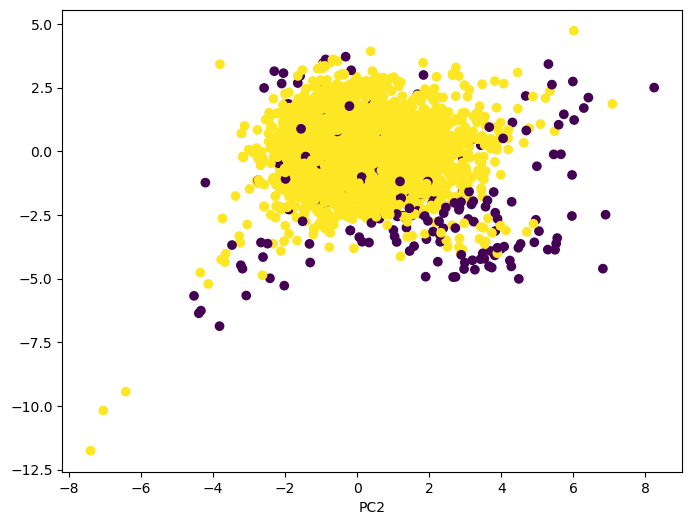

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel("PC1")
plt.xlabel("PC2")


In [18]:
import numpy as np
n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("n_outliers : ", n_outliers)
print("n_normal :", n_normal)

n_outliers :  208
n_normal : 6708


# LOF

In [21]:
from sklearn.neighbors import LocalOutlierFactor

In [29]:
neigh = LocalOutlierFactor(contamination=0.036)

labels = neigh.fit_predict(X_scaled)

Text(0, 0.5, 'PC2')

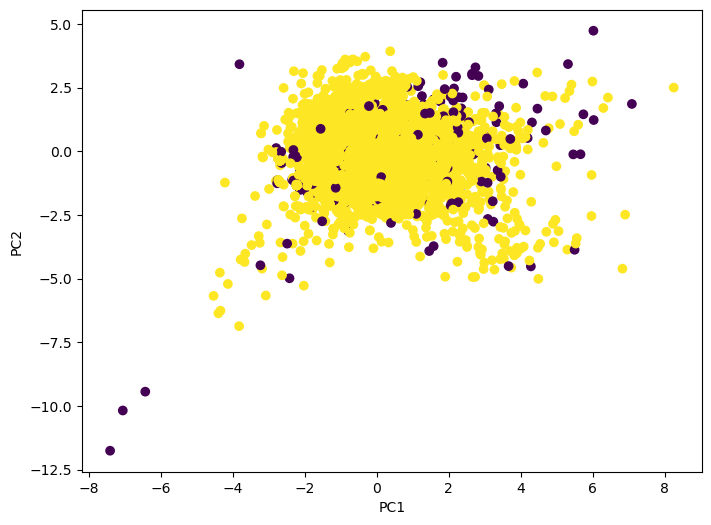

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")


In [31]:
import numpy as np
n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("n_outliers : ", n_outliers)
print("n_normal :", n_normal)

n_outliers :  249
n_normal : 6667
